<h1 style="text-align: center; color: red; font-size: 20px;">
 Analyse et visualisation des données Yelp avec Spark
</h1>
Par Dioumamane FALL, Thierno Daouda LY et Moussa SÈYE

<h2 style="text-align: center; color: red; font-size: 20px;">Introduction</h2>

La plupart des entreprises cherchent, d'une manière ou d'une autre, à recueillir des avis sur leurs produits et services. C'est un moyen essentiel pour améliorer leur efficacité et, par conséquent, leurs résultats. Cependant, obtenir des avis n'est pas une fin en soi : encore faut-il savoir les analyser, les structurer et les visualiser pour en tirer des enseignements utiles à la prise de décision.

Dans un contexte où les données générées par les utilisateurs (avis, notations, commentaires…) sont de plus en plus abondantes, les outils de la **data science** et du **Big Data** deviennent indispensables pour transformer cette matière brute en **valeur exploitable**.

Dans ce projet, nous travaillons à partir d’un **dataset public extrait de Yelp**, une plateforme en ligne qui permet aux utilisateurs de noter et commenter des commerces locaux comme des restaurants, des salons de coiffure, des bars ou encore des services divers. Le dataset comprend notamment des informations sur :

* les **entreprises** (localisation, catégorie, heures d’ouverture, etc.)
* les **utilisateurs** (profil, amis, ancienneté, nombre d’avis…)
* les **avis** (texte, note, date, votes utiles…)
* les **tips** (recommandations courtes)
* les **check-ins** (horaires de visite enregistrés)

L’objectif général de notre projet est d’**utiliser ce dataset public de Yelp pour effectuer une analyse descriptive** des données disponibles, et de **proposer des visualisations pertinentes** autour des entités principales : les commerces, les utilisateurs et les avis.

Pour cela, nous allons :

* Réaliser une analyse exploratoire (EDA) pour comprendre la structure des données et identifier les variables clés ;
* Formuler et explorer des questions analytiques simples et croisées (ex. : Qui sont les utilisateurs les plus actifs ? Quels types de commerces sont les mieux notés par ville ? Existe-t-il une corrélation entre ancienneté d’un utilisateur et utilité perçue de ses avis ?) ;
* Concevoir et calculer des scores d’activité, d’influence ou de confiance basés sur les métriques disponibles ;
* Générer des visualisations interactives ou statiques pour représenter les résultats de manière intuitive ;
* Travailler avec PySpark pour illustrer l’utilisation d’outils Big Data adaptés à la manipulation de données volumineuses, semi-structurées, et complexes.

<h2 style="text-align: center; color: red; font-size: 20px;"> Présentation du dataset Yelp </h2>

<img src="https://raw.githubusercontent.com/RepakaRamateja/YelpDataSet-Analysis-Visualisation/refs/heads/master/images/schema.png" width="100%">

La base de données **Yelp Academic Dataset** est distribuée sous forme de fichiers JSON, chacun représentant une entité distincte. Ces fichiers constituent les différentes briques d’un écosystème de données centré sur les interactions entre utilisateurs et commerces.

Elle se compose principalement de **cinq fichiers JSON essentiels** :

1. **`business.json`**
   Recense les informations sur les établissements présents sur Yelp : nom, adresse, coordonnées géographiques, nombre d’avis, note moyenne, catégories, etc.

2. **`user.json`**
   Contient des données sur les membres de la plateforme : historique d’activité (avis, tips), ancienneté, moyenne des notes attribuées, nombre de fans, etc.

3. **`review.json`**
   Regroupe les avis détaillés postés par les utilisateurs : note attribuée, contenu de l’avis, date de publication, ainsi que les votes communautaires (utile, drôle, cool).

4. **`checkin.json`**
   Enregistre les visites des utilisateurs dans les commerces, à travers des horodatages exploitables pour identifier les périodes de forte affluence.

5. **`tip.json`**
   Rassemble des conseils ou remarques concises laissés par les utilisateurs, souvent plus informels que les avis complets.

Un fichier PDF de documentation accompagne l’ensemble pour expliciter la structure et la signification de chaque champ.

Bien que livrée au format JSON, la base adopte une modélisation relationnelle rigoureuse, qui reflète la complexité et la richesse des interactions entre entités. Son organisation rappelle celle d’une base de données SQL, avec des **relations fortes entre entreprises, utilisateurs et contenus générés**.

L’élément central de cette base est la table **`business`**, représentant les établissements référencés sur Yelp. Chaque entrée décrit un commerce à travers des attributs variés : nom, localisation, évaluation moyenne, nombre d’avis, catégories, horaires, et caractéristiques diverses (Wi-Fi, accessibilité, etc.).

Autour de cette entité pivot gravitent plusieurs tables dites **secondaires**, qui enrichissent l’analyse :

* **`review`** : contient les avis détaillés, liés à une entreprise et à un utilisateur via les champs `business_id` et `user_id`.

* **`tip`** : recense des messages courts adressés aux entreprises, également associés à des utilisateurs.

* **`checkin`** : fournit des informations temporelles sur les visites, utiles pour analyser la fréquentation.

* **`photo`** : référence les images partagées par les utilisateurs, assorties de légendes.

* **`hours`** : précise les horaires d’ouverture hebdomadaires des établissements.

* **`category`** et **`attribute`** : décrivent respectivement les types de commerces et leurs spécificités (par exemple, présence d’un parking, d’un menu végétarien, etc.).

Enfin, la table **`user`** synthétise les profils des utilisateurs : nombre d’avis, moyenne de notes, date d’inscription, niveau d’influence (fans, compliments, statut élite...).

Les **relations sociales** entre membres sont modélisées par :

* **`friend`** : qui cartographie les liens d’amitié entre utilisateurs.

* **`elite_years`** : qui indique les années pendant lesquelles un utilisateur a obtenu le statut « élite », gage de contribution qualitative et soutenue à la communauté Yelp.

<h2 style="text-align: center; color: red; font-size: 20px;">
  Installation et importation des bibliothèques
</h2>

In [ ]:
! pip -q install findspark

In [ ]:
! pip -q install pandas matplotlib seaborn

In [ ]:
! pip -q install wget

  Preparing metadata (setup.py) ... done


In [ ]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import wget
import json
import findspark
from pyspark.sql.functions import col, count, desc, avg

<h2 style="text-align: center; color: red; font-size: 20px;">
  Création de la session Spark
</h2>

In [ ]:
spark = SparkSession.builder \
    .appName("YelpAnalysis") \
    .config("spark.ui.port", "4050") \
    .config("spark.driver.memory", "12g") \
    .getOrCreate()
sc = spark.sparkContext
print("La session est démarrée, son id est ", sc.applicationId)

La session est démarrée, son id est  local-1748853429722


<h2 style="text-align: center; color: red; font-size: 20px;">
  Téléchargement de la base de données
</h2>

In [ ]:
import requests
url = 'https://business.yelp.com/external-assets/files/Yelp-JSON.zip'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)

with open('yelp_dataset.zip', 'wb') as f:
    f.write(response.content)

print("Le dataset Yelp a été téléchargé avec succès !")

Le dataset Yelp a été téléchargé avec succès !


In [ ]:
# Creation d'un répertoire pour les données
! mkdir -p yelp_data

# Extraction des fichiers
! unzip -o yelp_dataset.zip -d yelp_data

# Lister les fichiers extraits
! ls -la yelp_data

Archive:  yelp_dataset.zip
   creating: yelp_data/Yelp JSON/
  inflating: yelp_data/Yelp JSON/Yelp Dataset Documentation & ToS copy.pdf  
  inflating: yelp_data/__MACOSX/Yelp JSON/._Yelp Dataset Documentation & ToS copy.pdf  
  inflating: yelp_data/Yelp JSON/yelp_dataset.tar  
  inflating: yelp_data/__MACOSX/Yelp JSON/._yelp_dataset.tar  
total 16
drwxr-xr-x 4 root root 4096 Jun  2 08:40  .
drwxr-xr-x 1 root root 4096 Jun  2 08:40  ..
drwxr-xr-x 3 root root 4096 Jun  2 08:40  __MACOSX
drwxr-xr-x 2 root root 4096 Jan  7 19:57 'Yelp JSON'


In [ ]:
import tarfile

# Chemin vers le fichier tar
tar_path = "/content/yelp_data/Yelp JSON/yelp_dataset.tar"

# Extraction
with tarfile.open(tar_path, 'r') as tar:
    tar.extractall(path="/content/yelp_data/extracted")

# Verification des fichiers extraits
!ls -la /content/yelp_data/extracted

total 9073960
drwxr-xr-x 2 root root        4096 Jun  2 08:43 .
drwxr-xr-x 5 root root        4096 Jun  2 08:41 ..
-rw-r--r-- 1 3559 users      80358 Feb 15  2022 Dataset_User_Agreement.pdf
-rw-r--r-- 1 3559 users  118863795 Jan 19  2022 yelp_academic_dataset_business.json
-rw-r--r-- 1 3559 users  286958945 Jan 19  2022 yelp_academic_dataset_checkin.json
-rw-r--r-- 1 3559 users 5341868833 Jan 19  2022 yelp_academic_dataset_review.json
-rw-r--r-- 1 3559 users  180604475 Jan 19  2022 yelp_academic_dataset_tip.json
-rw-r--r-- 1 3559 users 3363329011 Jan 19  2022 yelp_academic_dataset_user.json


<h2 style="text-align: center; color: red; font-size: 20px;">
  Exploitation de la base de données
</h2>

In [ ]:
# Fonction pour charger les fichiers JSON
def load_json_to_spark(file_path):
    return spark.read.json(file_path)

# Chargement des differents fichiers
business_df = load_json_to_spark("/content/yelp_data/extracted/yelp_academic_dataset_business.json")
review_df = load_json_to_spark("/content/yelp_data/extracted/yelp_academic_dataset_review.json")
user_df = load_json_to_spark("/content/yelp_data/extracted/yelp_academic_dataset_user.json")
checkin_df = load_json_to_spark("/content/yelp_data/extracted/yelp_academic_dataset_checkin.json")
tip_df = load_json_to_spark("/content/yelp_data/extracted/yelp_academic_dataset_tip.json")

# Afficher les schemas des fichiers

print("Schema du fichier Business :")
business_df.printSchema()

print("\n Schema du fichier Review :")
review_df.printSchema()

print("\n Schema du fichier User :")
user_df.printSchema()

print("\n Schema du fichier Checkin :")
checkin_df.printSchema()

print("\n Schema du fichier Tip :")
tip_df.printSchema()

Schema du fichier Business :
root
 |-- address: string (nullable = true)
 |-- attributes: struct (nullable = true)
 |    |-- AcceptsInsurance: string (nullable = true)
 |    |-- AgesAllowed: string (nullable = true)
 |    |-- Alcohol: string (nullable = true)
 |    |-- Ambience: string (nullable = true)
 |    |-- BYOB: string (nullable = true)
 |    |-- BYOBCorkage: string (nullable = true)
 |    |-- BestNights: string (nullable = true)
 |    |-- BikeParking: string (nullable = true)
 |    |-- BusinessAcceptsBitcoin: string (nullable = true)
 |    |-- BusinessAcceptsCreditCards: string (nullable = true)
 |    |-- BusinessParking: string (nullable = true)
 |    |-- ByAppointmentOnly: string (nullable = true)
 |    |-- Caters: string (nullable = true)
 |    |-- CoatCheck: string (nullable = true)
 |    |-- Corkage: string (nullable = true)
 |    |-- DietaryRestrictions: string (nullable = true)
 |    |-- DogsAllowed: string (nullable = true)
 |    |-- DriveThru: string (nullable = true)


In [ ]:
# Verification des donnees manquantes
def check_missing(df, name):
    print(f"\nDonnées manquantes dans {name}:")
    from pyspark.sql.functions import isnan, when, count, col
    df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

check_missing(business_df, "business")
check_missing(review_df, "review")
check_missing(user_df, "user")
check_missing(checkin_df, "checkin")
check_missing(tip_df, "tip")


Données manquantes dans business:
+-------+----------+-----------+----------+----+-----+-------+--------+---------+----+-----------+------------+-----+-----+
|address|attributes|business_id|categories|city|hours|is_open|latitude|longitude|name|postal_code|review_count|stars|state|
+-------+----------+-----------+----------+----+-----+-------+--------+---------+----+-----------+------------+-----+-----+
|      0|     13744|          0|       103|   0|23223|      0|       0|        0|   0|          0|           0|    0|    0|
+-------+----------+-----------+----------+----+-----+-------+--------+---------+----+-----------+------------+-----+-----+


Données manquantes dans review:
+-----------+----+----+-----+---------+-----+----+------+-------+
|business_id|cool|date|funny|review_id|stars|text|useful|user_id|
+-----------+----+----+-----+---------+-----+----+------+-------+
|          0|   0|   0|    0|        0|    0|   0|     0|      0|
+-----------+----+----+-----+---------+-----+--

In [ ]:
# Afficher le nombre d'enregistrements dans chaque dataframe
print(f"Nombre d'entreprises : {business_df.count()}")
print(f"Nombre d'avis : {review_df.count()}")
print(f"Nombre d'utilisateurs : {user_df.count()}")
print(f"Nombre de check-ins : {checkin_df.count()}")
print(f"Nombre de conseils : {tip_df.count()}")

# Verifier les valeurs manquantes
print("\nVérification des valeurs manquantes dans business_df :")
from pyspark.sql.functions import col
for col_name in business_df.columns:
    missing_count = business_df.filter(col(col_name).isNull()).count()
    if missing_count > 0:
        print(f"{col_name}: {missing_count} ({missing_count/business_df.count()*100:.2f}%)")

# Verifier les doublons dans les IDs
print("\nDoublons dans business_id :", business_df.select("business_id").distinct().count() != business_df.count())
print("Doublons dans user_id :", user_df.select("user_id").distinct().count() != user_df.count())
print("Doublons dans review_id :", review_df.select("review_id").distinct().count() != review_df.count())

Nombre d'entreprises : 150346
Nombre d'avis : 6990280
Nombre d'utilisateurs : 1987897
Nombre de check-ins : 131930
Nombre de conseils : 908915

Vérification des valeurs manquantes dans business_df :
attributes: 13744 (9.14%)
categories: 103 (0.07%)
hours: 23223 (15.45%)

Doublons dans business_id : False
Doublons dans user_id : False
Doublons dans review_id : False


<h2 style="text-align: center; color: red; font-size: 20px;">
  Pré-traitement des données
</h2>

In [ ]:
from pyspark.sql.functions import col, explode, split, length, when, size, to_timestamp, datediff, current_timestamp
from pyspark.sql.types import ArrayType, StringType

# Nettoyage des donnees business
print("Nettoyage des données business...")

# Conversion de la colonne categories en array pour faciliter l'analyse
business_clean = business_df.withColumn(
    "categories_array",
    when(col("categories").isNotNull(), split(col("categories"), ", ")).otherwise(None)
)

# Filtrage des commerces invalides ou incomplets
business_clean = business_clean.filter(
    (col("categories").isNotNull()) &
    (col("latitude").isNotNull()) &
    (col("longitude").isNotNull()) &
    (col("name").isNotNull()) &
    (col("stars").isNotNull()) &
    (col("review_count") > 0)
)

# Convertir les attributs et heures (qui sont des structures) en chaînes pour faciliter l'extraction ultérieure
business_attrs = ["RestaurantsPriceRange2", "WiFi", "OutdoorSeating", "Alcohol"]
for attr in business_attrs:
    business_clean = business_clean.withColumn(
        attr,
        when(col("attributes").isNotNull(), col(f"attributes.{attr}")).otherwise(None)
    )

print(f"Nombre d'entreprises après nettoyage : {business_clean.count()}")

Nettoyage des données business...
Nombre d'entreprises après nettoyage : 150243


In [ ]:
# Nettoyage des donnees review
print("\nNettoyage des données review...")

# Convertir la date en timestamp et ajouter des colonnes d'analyse
review_clean = review_df.withColumn("date_timestamp", to_timestamp(col("date"))) \
                       .withColumn("text_length", length(col("text")))

# Filtrer les avis sans texte ou notes
review_clean = review_clean.filter(
    (col("text").isNotNull()) &
    (col("text_length") > 0) &
    (col("stars").isNotNull())
)

print(f"Nombre d'avis après nettoyage: {review_clean.count()}")


Nettoyage des données review...
Nombre d'avis après nettoyage: 6990280


In [ ]:
# Nettoyage des donnees user
print("\nNettoyage des données user...")

# Transformation de la colonne elite en array et calcul du nombre d'années élite
user_clean = user_df.withColumn(
    "elite_years",
    when(col("elite").isNotNull() & (col("elite") != ""), split(col("elite"), ",")).otherwise(None)
)

# Calcul du nombre d'années élite
user_clean = user_clean.withColumn(
    "elite_count",
    when(col("elite_years").isNotNull(), size(col("elite_years"))).otherwise(0)
)

# Calcul de l'ancienneté du compte
user_clean = user_clean.withColumn("yelping_since_date", to_timestamp(col("yelping_since"))) \
                      .withColumn("account_age_days", datediff(current_timestamp(), col("yelping_since_date")))

# Extraction du nombre d'amis
user_clean = user_clean.withColumn(
    "friends_array",
    when(col("friends").isNotNull() & (col("friends") != "None"), split(col("friends"), ", ")).otherwise(None)
)

user_clean = user_clean.withColumn(
    "friends_count",
    when(col("friends_array").isNotNull(), size(col("friends_array"))).otherwise(0)
)

print(f"Nombre d'utilisateurs après nettoyage: {user_clean.count()}")


Nettoyage des données user...
Nombre d'utilisateurs après nettoyage: 1987897


In [ ]:
# Nettoyage des donnees checkin
print("\nNettoyage des données checkin...")

# Transformation de la colonne date (qui contient plusieurs dates séparées par des virgules) en array
checkin_clean = checkin_df.withColumn(
    "date_array",
    when(col("date").isNotNull(), split(col("date"), ", ")).otherwise(None)
)

# Calcul du nombre de check-ins par business
checkin_clean = checkin_clean.withColumn(
    "checkin_count",
    when(col("date_array").isNotNull(), size(col("date_array"))).otherwise(0)
)

print(f"Nombre de check-ins après nettoyage: {checkin_clean.count()}")


Nettoyage des données checkin...
Nombre de check-ins après nettoyage: 131930


In [ ]:
# Nettoyage des données tip
print("\nNettoyage des données tip...")

# Conversion de la date en timestamp
tip_clean = tip_df.withColumn("date_timestamp", to_timestamp(col("date")))

print(f"Nombre de tips après nettoyage: {tip_clean.count()}")


Nettoyage des données tip...
Nombre de tips après nettoyage: 908915


In [ ]:
# Nettoyage des donnees tip
print("\nNettoyage des données user...")

# Conversion de la date d'inscription
user_clean = user_df.withColumn("yelping_since", to_timestamp(col("yelping_since")))

# Filtrage des lignes invalides
user_clean = user_clean.filter(
    (col("user_id").isNotNull()) &
    (col("name").isNotNull()) &
    (col("yelping_since").isNotNull())
)

# Conversion de la colonne "friends" en array et calcul du nombre d'amis
user_clean = user_clean.withColumn(
    "friend_count",
    when(col("friends").isNotNull(), size(split(col("friends"), ","))).otherwise(0)
)

print(f"Nombre d'utilisateurs après nettoyage : {user_clean.count()}")


Nettoyage des données user...
Nombre d'utilisateurs après nettoyage : 1987897


<h2 style="text-align: center; color: red; font-size: 20px;">
  Création des vues temporaires pour faciliter les requêtes SQL
</h2>

In [ ]:
business_clean.createOrReplaceTempView("business")
review_clean.createOrReplaceTempView("review")
user_clean.createOrReplaceTempView("user")
checkin_clean.createOrReplaceTempView("checkin")
tip_clean.createOrReplaceTempView("tip")

print("Vues temporaires créées avec succès.")

Vues temporaires créées avec succès.


<h2 style="text-align: center; color: red; font-size: 20px;">
  Analyse exploratoire du dataset Yelp
</h2>

### 1. Top 10 des villes avec le plus de commerces :  

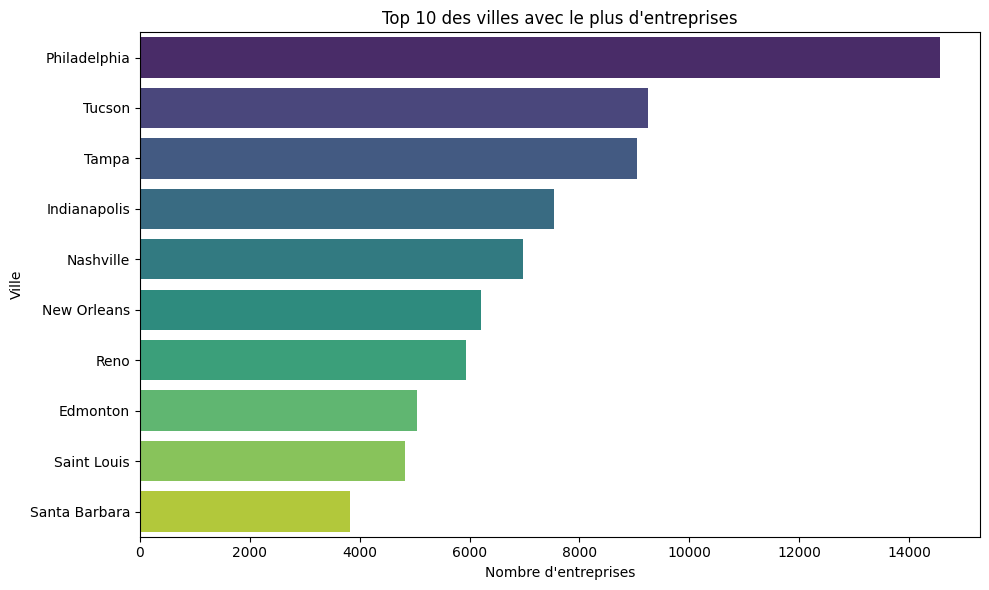

In [ ]:
top_cities = spark.sql("""
    SELECT city, COUNT(*) as nb_business
    FROM business
    GROUP BY city
    ORDER BY nb_business DESC
    LIMIT 10
""").toPandas()

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cities, x="nb_business", y="city", hue="city", palette="viridis")
plt.title("Top 10 des villes avec le plus d'entreprises")
plt.xlabel("Nombre d'entreprises")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()

Cette forte présence de commerces dans ces 10 grandes villes peut s’expliquer par leur attractivité touristique, leur taille, leur activité économique et leur adoption du numérique.

### 2. Les villes avec la meilleure note moyenne :

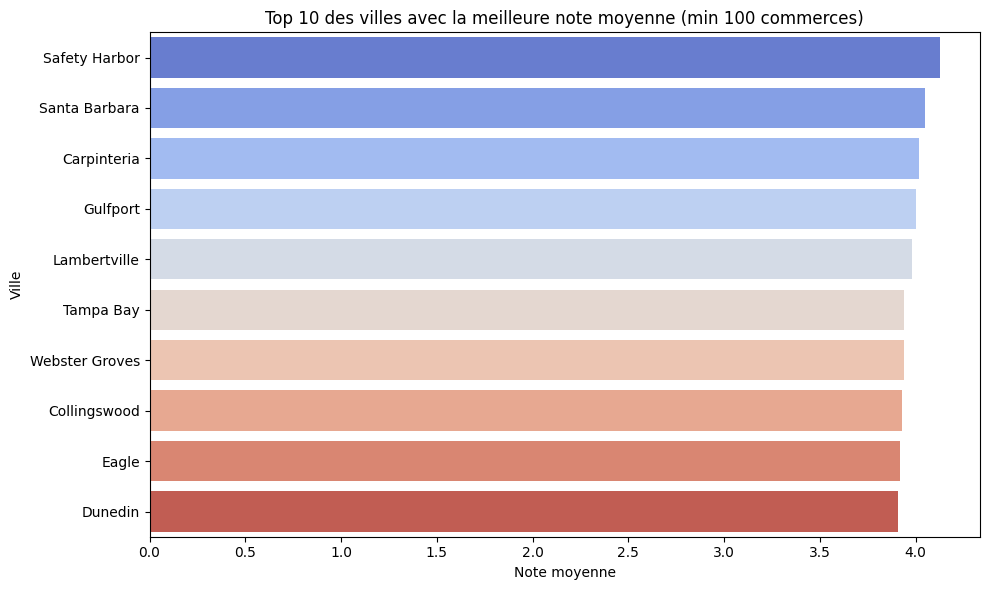

In [ ]:
avg_stars_by_city = spark.sql("""
    SELECT city, ROUND(AVG(stars), 2) as avg_rating, COUNT(*) as nb_business
    FROM business
    GROUP BY city
    HAVING nb_business > 100
    ORDER BY avg_rating DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_stars_by_city, x="avg_rating", y="city", hue="city", palette="coolwarm")
plt.title("Top 10 des villes avec la meilleure note moyenne (min 100 commerces)")
plt.xlabel("Note moyenne")
plt.ylabel("Ville")
plt.tight_layout()
plt.show()

Bien que plusieurs villes aient des moyennes proches de 5, on note une homogénéité autour de 4 étoiles. Cela montre que globalement, les commerces sont bien notés, et qu’il existe peu de disparités importantes entre villes, au moins parmi celles ayant un volume significatif d’activités.

### 3. Top 10 commerces avec le plus de check-ins :

In [ ]:
from pyspark.sql.functions import desc

top_checkins = checkin_clean.groupBy("business_id") \
    .count() \
    .orderBy(desc("count")) \
    .limit(10) \
    .alias("top_checkin")

top_checkins_named = top_checkins.join(
    business_clean.select("business_id", "name"),
    on="business_id"
)

top_checkins_pd = top_checkins_named.select("name").toPandas()
top_checkins_pd.style.set_caption("")

,name
0,Richman's Ice Cream & Burger
1,Blue Danube
2,Chipotle Mexican Grill
3,New Orleans Original Daiquiris
4,Fish Tail Willys
5,Scotty's Brewhouse
6,Truckee Bagel Company - Midtown
7,Best Smoke
8,New Hope Pet Center
9,Family Holland Dental


### 4. Les catégories d'enseignes les plus fréquentes :

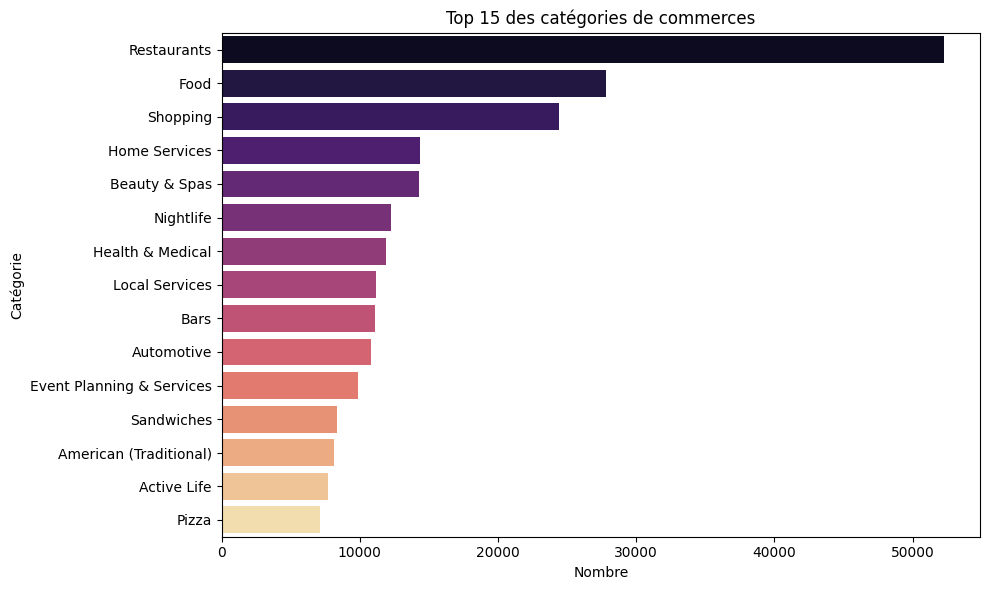

In [ ]:
# Exploser les catégories en lignes
from pyspark.sql.functions import explode

categories_df = business_clean.select(explode("categories_array").alias("category"))
top_categories = categories_df.groupBy("category").count().orderBy("count", ascending=False).limit(15).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, x="count", y="category", hue="category", legend=False, palette="magma")
plt.title("Top 15 des catégories de commerces")
plt.xlabel("Nombre")
plt.ylabel("Catégorie")
plt.tight_layout()
plt.show()

Les catégories les plus fréquentes sont dominées par des services de proximité (restaurants, soins de beauté, santé, services auto). Cela reflète les secteurs pour lesquels les utilisateurs ressentent le besoin de consulter ou laisser des avis. Ceci montre donc que Yelp est principalement utilisé pour des besoins locaux et quotidiens.

### 5. Les catégories de commerce les plus consultés par année (ie avec le plus grand nombre d'avis) :

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

jointure = spark.sql("""
    SELECT
        YEAR(r.date) AS annee,
        b.categories AS categorie,
        COUNT(*) AS nb_avis
    FROM review r
    JOIN business b ON r.business_id = b.business_id
    GROUP BY annee, b.categories
""")

window = Window.partitionBy("annee").orderBy(F.desc("nb_avis"))
classement = jointure.withColumn("rang", F.row_number().over(window))
top3_par_annee = classement.filter("rang <= 3") \
                           .select("annee", "categorie", "nb_avis") \
                           .orderBy("annee", "rang")

top3_par_annee_pd = top3_par_annee.toPandas()
top3_par_annee_pd.style.set_caption("").format({"nb_avis": "{:,}"})

,annee,categorie,nb_avis
0,2005,"Mexican, Restaurants",11
1,2005,"Bars, Nightlife",11
2,2005,"Italian, Restaurants",10
3,2006,"Restaurants, Mexican",55
4,2006,"Mexican, Restaurants",38
5,2006,Restaurants,32
6,2007,"Restaurants, Mexican",186
7,2007,"Mexican, Restaurants",132
8,2007,"Pizza, Restaurants",102
9,2008,"Restaurants, Mexican",534


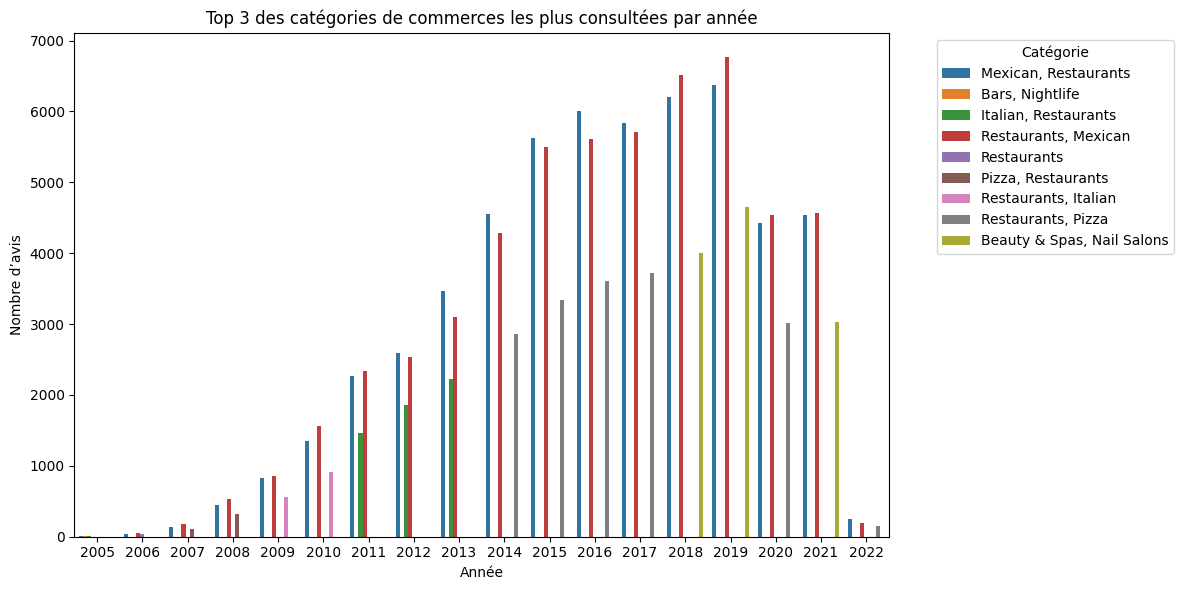

In [ ]:
top3_pd = top3_par_annee.toPandas()

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.barplot(data=top3_pd, x="annee", y="nb_avis", hue="categorie")
plt.title("Top 3 des catégories de commerces les plus consultées par année")
plt.xlabel("Année")
plt.ylabel("Nombre d’avis")
plt.legend(title="Catégorie", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Les restaurants mexicains dominent largement les consultations sur Yelp depuis 2005, apparaissant systématiquement dans le top 3 — et souvent en première position. Cette régularité s’explique par plusieurs facteurs tels que:

1. la popularité culturelle croissante : la cuisine mexicaine a connu une forte expansion aux États-Unis et au Canada dans les années 2000, soutenue par une vague de démocratisation des cuisines ethniques (tacos, burritos, guacamole… devenus grand public).

2. l'offre massive sur Yelp : de nombreuses chaînes de restaurants (comme Chipotle ou Taco Bell) ainsi que des établissements indépendants mexicains sont très présents sur Yelp, ce qui augmente mécaniquement leur visibilité et leur volume d’avis.

3. les prix abordables : la cuisine mexicaine est généralement bon marché et accessible, ce qui attire un large public — notamment les jeunes utilisateurs de Yelp, friands de bons plans culinaires.

4. le caractère social : ce type de cuisine est souvent associé à des expériences conviviales et informelles (restauration rapide, food trucks, partages entre amis), propices aux avis et recommandations.

### 6. Les 10 villes avec la meilleure note moyenne (≥3) :

In [ ]:
top_rated_cities = business_clean.groupBy("city") \
    .agg(avg("stars").alias("avg_rating")) \
    .filter("avg_rating >= 3") \
    .orderBy(desc("avg_rating")) \
    .limit(10)

top_rated_cities_pd = top_rated_cities.toPandas()
top_rated_cities_pd.style.set_caption("").format({"avg_rating": "{:.2f}"})

,city,avg_rating
0,"Eagle,",5.00
1,Fernley,5.00
2,Picture Rocks,5.00
3,MERIDIAN,5.00
4,Ellisville,5.00
5,Lutz fl,5.00
6,Covington,5.00
7,Webster Grvs,5.00
8,MIDDLE CITY WEST,5.00
9,COLMAR,5.00


### 7. Les types de commerces reçoivent les meilleures notes :

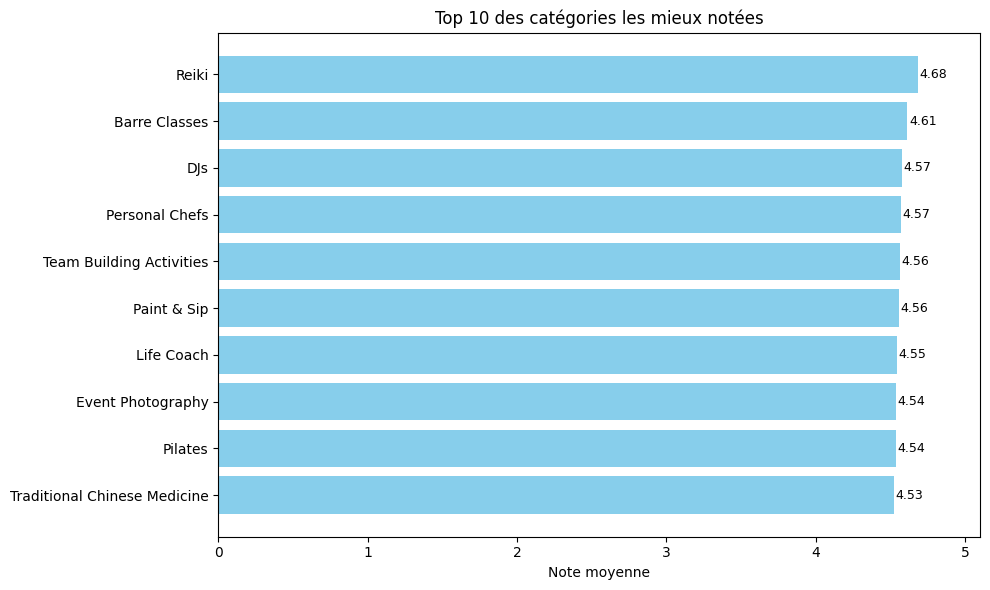

In [ ]:
from pyspark.sql.functions import explode, avg, count, col
import matplotlib.pyplot as plt

# On éclate les catégories
categories_avg = business_clean.select(
    explode("categories_array").alias("category"),
    "stars"
)

# Calcul moyenne et nombre par catégorie
categories_stats = categories_avg.groupBy("category") \
    .agg(
        avg("stars").alias("avg_rating"),
        count("*").alias("nb_business")
    ) \
    .filter(col("nb_business") > 100) \
    .orderBy(col("avg_rating").desc())

# Conversion en DataFrame Pandas
categories_stats_pd = categories_stats.limit(10).toPandas()

# Affichage
plt.figure(figsize=(10, 6))
bars = plt.barh(categories_stats_pd["category"], categories_stats_pd["avg_rating"], color='skyblue')
plt.xlabel("Note moyenne")
plt.title("Top 10 des catégories les mieux notées")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f"{width:.2f}", va='center', fontsize=9)

plt.xlim(0, 5.1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Certaines catégories de niche comme les "Escape Games", "Massages thérapeutiques", ou "Barbiers" obtiennent des moyennes très élevées. Ces expériences, souvent immersives ou personnalisées, génèrent plus d’enthousiasme chez les clients, expliquant des notes globalement élevées.

### 8. Distribution du nombre d'avis par note :

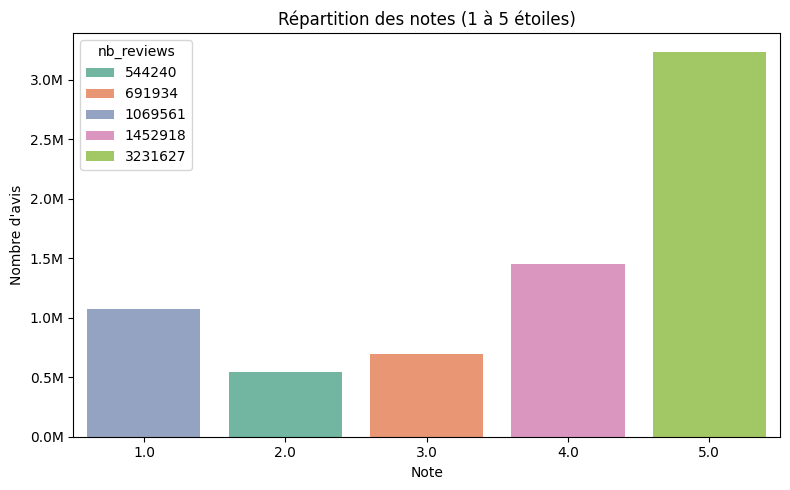

In [ ]:
ratings_df = spark.sql("""
    SELECT stars, COUNT(*) as nb_reviews
    FROM review
    GROUP BY stars
    ORDER BY stars
""").toPandas()

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(8, 5))
sns.barplot(data=ratings_df, x="stars", y="nb_reviews", hue="nb_reviews", palette="Set2")
plt.title("Répartition des notes (1 à 5 étoiles)")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

La majorité des avis sont positifs (4 et 5 étoiles). Cela traduit un biais de positivité, courant dans les plateformes d’avis. Peu de personnes prennent le temps de laisser un avis neutre ou négatif, sauf si l’expérience a été particulièrement décevante.

### 9. Évolution du nombre d’avis par année :

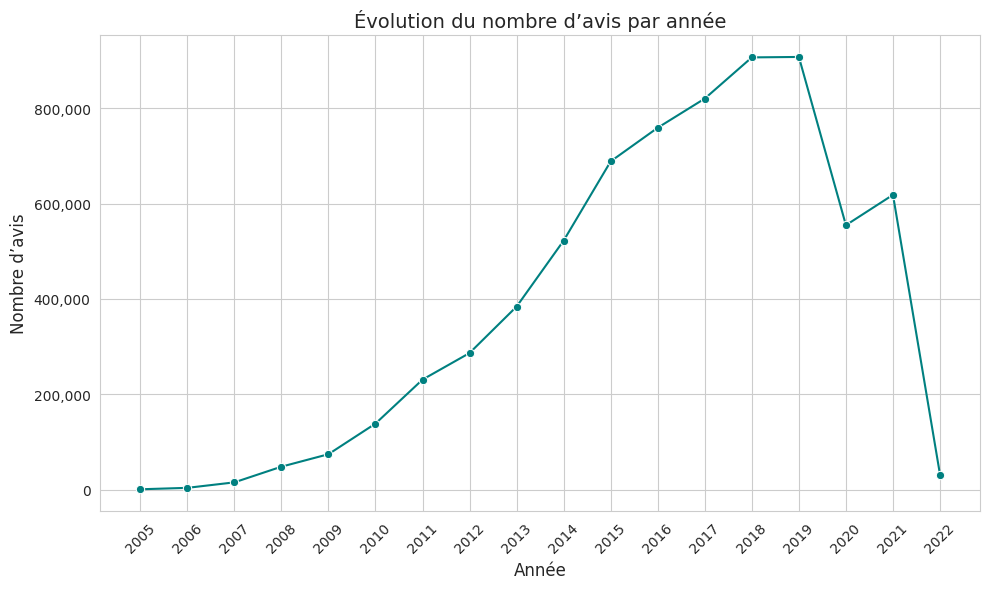

In [ ]:
from pyspark.sql.functions import year, to_date
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

review_year = review_clean.withColumn("year", year(to_date("date"))) \
    .groupBy("year") \
    .count() \
    .orderBy("year")

review_year_pd = review_year.toPandas()

review_year_pd["year"] = review_year_pd["year"].astype(int)

review_year_pd = review_year_pd.sort_values("year")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(data=review_year_pd, x="year", y="count", marker="o", color="teal")

plt.title("Évolution du nombre d’avis par année", fontsize=14)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d’avis", fontsize=12)

plt.xticks(ticks=review_year_pd["year"].unique(), rotation=45)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

On observe une nette progression du nombre d’avis au fil des années, avec un ralentissement à partir de 2019. Cela pourrait s’expliquer par une maturation de la plateforme, des changements d’usage (ex. : plus de "likes", moins de textes) ou l’impact de facteurs externes (COVID-19 par exemple).

### 10. Nombre moyen de mots par avis :

In [ ]:
from pyspark.sql.functions import length

avg_length = review_clean.withColumn("text_length", length("text")) \
    .selectExpr("avg(text_length) as avg_length") \
    .collect()[0]["avg_length"]

print(f"La longueur moyenne des avis est de {avg_length:.2f} caractères")

La longueur moyenne des avis est de 567.76 caractères


La longueur moyenne d’un avis est d’environ 567 caractères, ce qui montre que les utilisateurs prennent le temps de rédiger un commentaire relativement détaillé. Cela permet ainsi de mieux comprendre les expériences clients au-delà des notes.

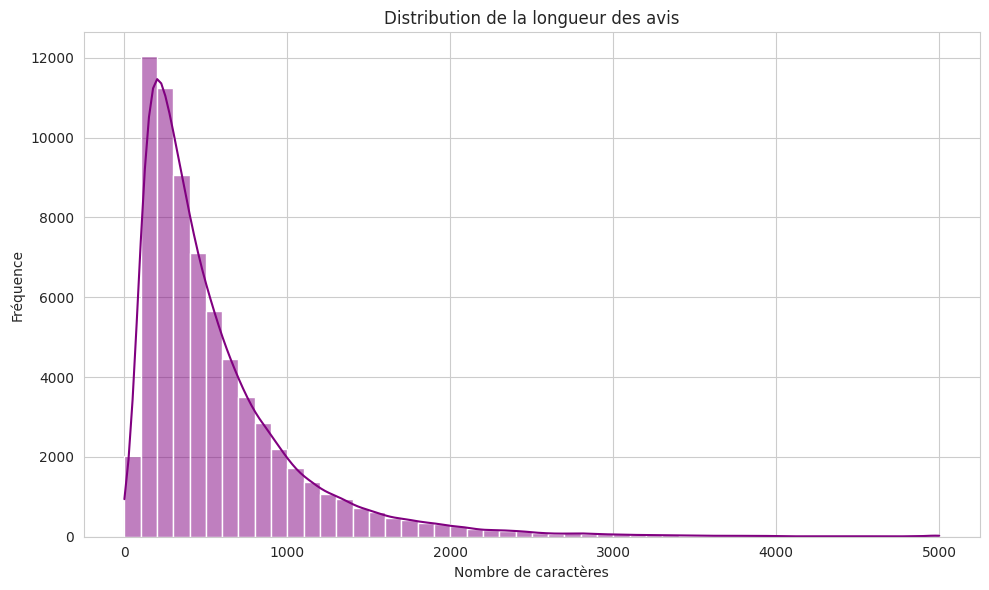

In [ ]:
import seaborn as sns

text_lengths = review_clean.withColumn("text_length", length("text")) \
    .select("text_length") \
    .sample(False, 0.01)
text_lengths_pd = text_lengths.toPandas()

plt.figure(figsize=(10,6))
sns.histplot(text_lengths_pd["text_length"], bins=50, color="purple", kde=True)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Nombre de caractères")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

On voit que des commentaires de plus de 3000 mots sont quasi inexistents.

### 11. Top 10 des utilisateurs avec le plus d'avis :

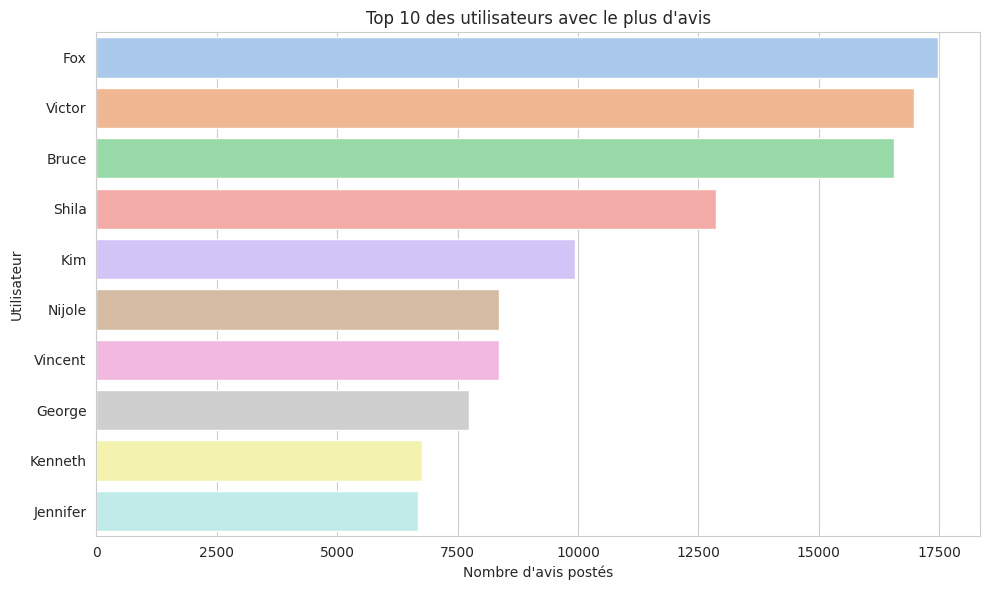

In [ ]:
active_users = spark.sql("""
    SELECT user_id, name, review_count
    FROM user
    ORDER BY review_count DESC
    LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=active_users, x="review_count", y="name", hue="name", palette="pastel")
plt.title("Top 10 des utilisateurs avec le plus d'avis")
plt.xlabel("Nombre d'avis postés")
plt.ylabel("Utilisateur")
plt.tight_layout()
plt.show()

### 12. Top 10 des utilisateurs les plus actifs (nombre total d'avis + tips + check-ins) :

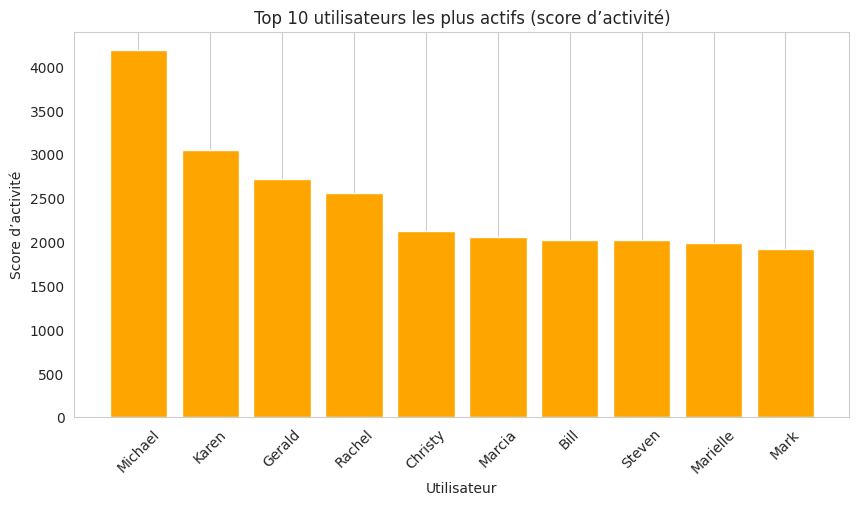

In [ ]:
from pyspark.sql.functions import coalesce
from pyspark.sql.functions import lit

review_count_df = review_df.groupBy("user_id").count().withColumnRenamed("count", "review_count")
tip_count_df = tip_df.groupBy("user_id").count().withColumnRenamed("count", "tip_count")
activity_score_df = user_df.select("user_id", "name").join(review_count_df, "user_id", "left") \
                           .join(tip_count_df, "user_id", "left") \
                           .withColumn("activity_score", coalesce(col("review_count"), lit(0)) + coalesce(col("tip_count"), lit(0)))

top_active_users = activity_score_df.orderBy(col("activity_score").desc()).limit(10)

import matplotlib.pyplot as plt
top_pd = top_active_users.toPandas()
plt.figure(figsize=(10,5))
plt.bar(top_pd["name"], top_pd["activity_score"], color="orange")
plt.xticks(rotation=45)
plt.title("Top 10 utilisateurs les plus actifs (score d’activité)")
plt.ylabel("Score d’activité")
plt.xlabel("Utilisateur")
plt.grid(axis="y")
plt.show()

### 13. Top 10 des  utilisateurs avec le plus de fans :

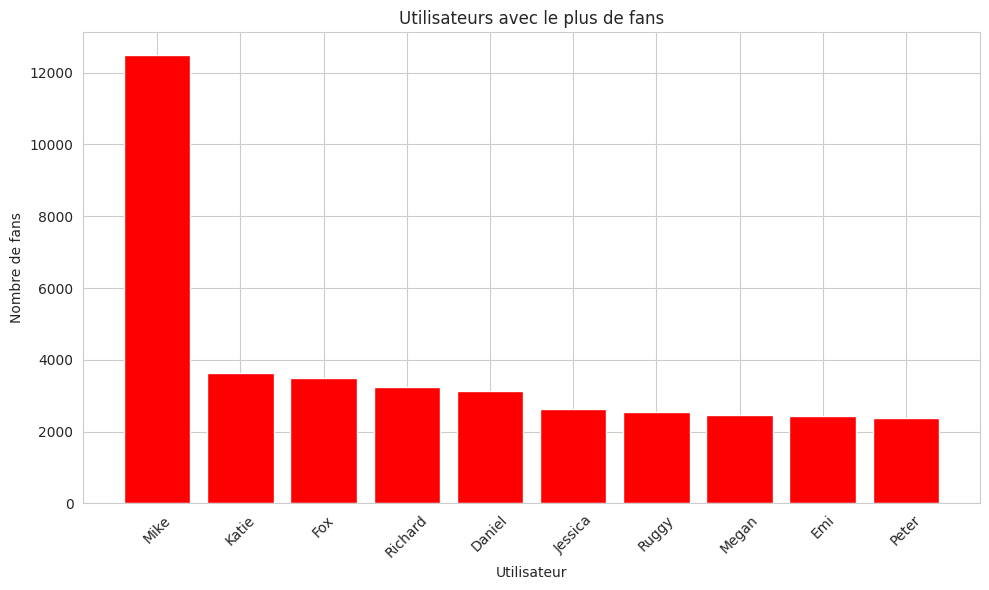

In [ ]:
top_users = user_clean.select("name", "fans") \
    .orderBy(desc("fans")) \
    .limit(10)
top_users_pd = top_users.toPandas()

plt.figure(figsize=(10,6))
plt.bar(top_users_pd["name"], top_users_pd["fans"], color='red')
plt.title("Utilisateurs avec le plus de fans")
plt.xlabel("Utilisateur")
plt.ylabel("Nombre de fans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 14. Top 10 utilisateurs les plus influents (nombre de fans + nombre de compliments + utilité des avis) :

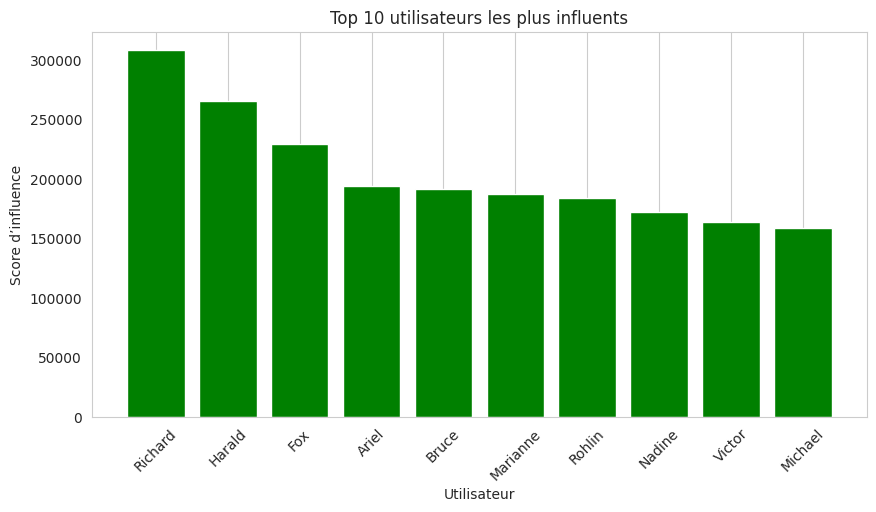

In [ ]:
influence_df = user_df.select("user_id", "name", "fans", "useful", "compliment_hot", "compliment_cool", "compliment_funny") \
    .withColumn("influence_score",
                col("fans") + col("useful") + col("compliment_hot") + col("compliment_cool") + col("compliment_funny"))

top_influencers = influence_df.orderBy(col("influence_score").desc()).limit(10)

top_inf_pd = top_influencers.toPandas()
plt.figure(figsize=(10,5))
plt.bar(top_inf_pd["name"], top_inf_pd["influence_score"], color="green")
plt.xticks(rotation=45)
plt.title("Top 10 utilisateurs les plus influents")
plt.ylabel("Score d’influence")
plt.xlabel("Utilisateur")
plt.grid(axis="y")
plt.show()

### 15. Top 10 utilisateurs les plus fiables en terme de score de confiance (moyenne des notes données vs notes moyennes de la communauté)

In [ ]:
from pyspark.sql.functions import avg, col, abs
import pandas as pd

# Moyenne des notes par utilisateur
user_avg_rating = review_df.groupBy("user_id").agg(avg("stars").alias("user_avg_rating"))

# Moyenne globale
global_avg_rating = review_df.agg(avg("stars")).first()[0]

# Calcul du score de confiance (écart faible = plus fiable)
user_trust_score = user_avg_rating.withColumn("trust_score",
                        1 / (abs(col("user_avg_rating") - global_avg_rating) + 1)) \
                        .join(user_df.select("user_id", "name"), "user_id")

top_trust = user_trust_score.orderBy(col("trust_score").desc()).limit(10)
top_trust_clean = top_trust.select("name", "user_avg_rating", "trust_score")
top_trust_df = top_trust_clean.toPandas()

# Arrondir les colonnes numériques
top_trust_df["user_avg_rating"] = top_trust_df["user_avg_rating"].round(2)
top_trust_df["trust_score"] = top_trust_df["trust_score"].round(4)

top_trust_df.columns = ["Utilisateur", "Note moyenne", "Score de confiance"]

from IPython.display import display
display(top_trust_df.style.set_caption("")
                        .format(precision=2)
                        .background_gradient(subset=["Score de confiance"]))

,Utilisateur,Note moyenne,Score de confiance
0,Vicki,3.75,1.00
1,RuthMarie,3.75,1.00
2,Virginia,3.75,1.00
3,Namir,3.75,1.00
4,Vi,3.75,1.00
5,Mary,3.75,1.00
6,Robert,3.75,1.00
7,Benjamin,3.75,1.00
8,Bob,3.75,1.00
9,Blake,3.75,1.00


Les utilisateurs les plus fiables sont ceux dont la moyenne de notation est proche de la moyenne globale. Leur comportement est donc plus "neutre" ou représentatif de l’ensemble. Cela peut refléter une forme d’objectivité ou de régularité dans l’évaluation.

### 16. Corrélation note moyenne et nombre d’avis :

Corrélation entre les notes et le nombre d’avis : 0.0596



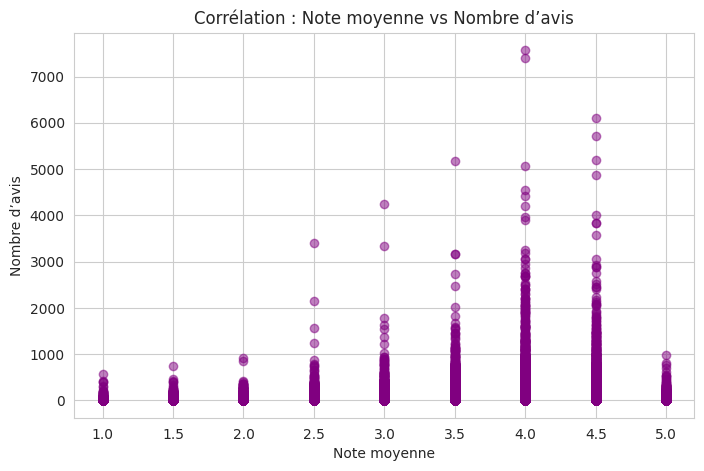

In [ ]:
# Recuperer les colonnes pertinentes
corr_df = business_clean.select("stars", "review_count")

# Corrélation mathématique
correlation = corr_df.corr("stars", "review_count")
print(f"Corrélation entre les notes et le nombre d’avis : {correlation:.4f}\n")

corr_pd = corr_df.toPandas()
plt.figure(figsize=(8,5))
plt.scatter(corr_pd["stars"], corr_pd["review_count"], alpha=0.5, c='purple')
plt.xlabel("Note moyenne")
plt.ylabel("Nombre d’avis")
plt.title("Corrélation : Note moyenne vs Nombre d’avis")
plt.grid(True)
plt.show()

La corrélation entre la note moyenne (stars) d’un commerce et son nombre d’avis est faible. Une note élevée ne garantit pas un grand nombre d’avis, et inversement et un commerce très bien noté peut être nouveau ou peu fréquenté, donc peu évalué. À l’inverse, des commerces très populaires peuvent avoir beaucoup d’avis variés, ce qui tend leur moyenne vers des valeurs plus modérées (entre 3.5 et 4).

### 17. Corrélation entre le prix moyen et la note :

Corrélation entre le prix moyen et la note : 0.0720



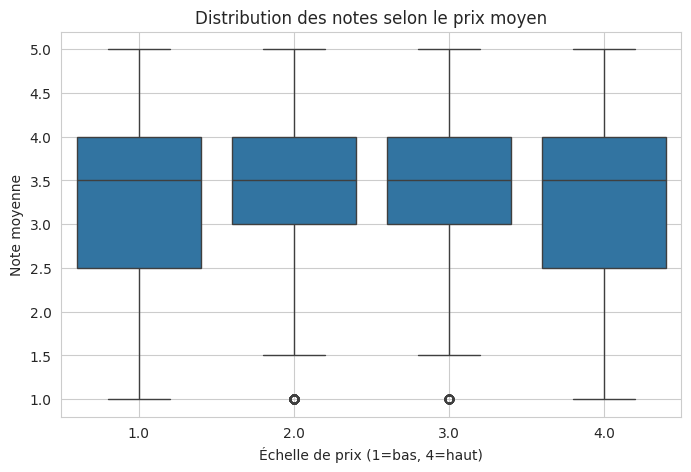

In [ ]:
price_df = business_clean.filter(col("RestaurantsPriceRange2").isNotNull()) \
                         .select(col("stars"), col("RestaurantsPriceRange2").cast("int").alias("price_range"))

price_corr = price_df.corr("price_range", "stars")
print(f"Corrélation entre le prix moyen et la note : {price_corr:.4f}\n")

import seaborn as sns
price_pd = price_df.toPandas()
plt.figure(figsize=(8,5))
sns.boxplot(x="price_range", y="stars", data=price_pd)
plt.xlabel("Échelle de prix (1=bas, 4=haut)")
plt.ylabel("Note moyenne")
plt.title("Distribution des notes selon le prix moyen")
plt.grid(True)
plt.show()

Les notes moyennes attribuées aux commerces ne varient pas significativement selon leur niveau de prix. Quelle que soit l’échelle de prix (de 1 à 4), les médianes restent proches, autour de 3,5 à 4, avec des distributions similaires. Cela suggère que le prix n’est pas un facteur déterminant dans la satisfaction des clients: les établissements bon marché peuvent être aussi bien notés que ceux plus coûteux. D’autres éléments comme la qualité du service ou l’expérience client semblent donc avoir plus d’impact sur la perception globale.

<h2 style="text-align: center; color: red; font-size: 20px;">
  Conclusion
</h2>

Ce projet d’analyse et de visualisation du dataset Yelp a permis d’extraire une vision d’ensemble des dynamiques entre utilisateurs, commerces et avis. Grâce à l’utilisation de Spark pour le traitement massif de données, nous avons pu explorer plusieurs dimensions clés : répartition géographique des commerces, comportements des utilisateurs, tendances d’évaluation, et relations entre note, activité et prix.
Les visualisations réalisées ont permis de révéler des patterns intéressants, comme la concentration des commerces bien notés dans certaines villes, la corrélation modérée entre activité et réputation, ou encore l’équilibre relatif des notes à travers les différentes gammes de prix.
Bien que certaines limites du dataset aient restreint l’analyse (absence de contexte temporel précis, données textuelles manquantes), les pistes ouvertes restent nombreuses. À terme, une intégration de données externes, l’usage de modèles de recommandation et une interface interactive pourraient transformer cette étude descriptive en un outil puissant d’aide à la décision pour les consommateurs comme pour les professionnels.